# Experiment 5: Aesthetic Neurons — Causal Identification via Ablation

**Research Question**: Are there individual neurons (or small groups) that are **causally necessary** for aesthetic judgment? If we ablate them, does the model lose its ability to generate beautiful language?

**Approach**:
1. Compute per-neuron **aesthetic selectivity** from Exp 2 activations (Cohen's d, direction weight, contribution)
2. **Offline AUC analysis**: mask neurons in saved activations → measure classification drop
3. **Single-neuron ablation**: ablate top neurons one-at-a-time → measure generation vocabulary change
4. **Group ablation sweep**: ablate top-N simultaneously → find the "tipping point"
5. **Random control**: compare with random neuron ablation → prove specificity
6. **Layer sensitivity**: which layers are most vulnerable to aesthetic neuron ablation?

**Model**: Qwen3-8B Q4_K_M (36 layers, 4096 dim)  
**Builds on**: Experiment 2 (aesthetic direction, raw activations, best layer = 16)

## §1 Setup

In [31]:
import os, sys, time, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'

sys.path.insert(0, '/workspace/NeuroScope/build/python')
import neuroscope

# CJK fonts
for f in fm.findSystemFonts():
    if 'noto' in f.lower() and 'cjk' in f.lower():
        fm.fontManager.addfont(f)
plt.rcParams.update({
    'font.family': ['Noto Sans CJK SC', 'sans-serif'],
    'axes.unicode_minus': False,
    'figure.dpi': 150,
    'figure.facecolor': 'white',
})
print(f'NeuroScope {neuroscope.__version__}, CUDA: {neuroscope.cuda_available()}')

NeuroScope 1.2.3, CUDA: True


In [2]:
# §2 Config + helpers
MODEL_PATH = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
EXP2_DIR = Path('/workspace/Data/aesthetic_experiment')
OUTPUT_DIR = Path('/workspace/Data/aesthetic_neurons')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NOTHINK_SUFFIX = '<think>\n\n</think>\n\n'
SEED = 42
np.random.seed(SEED)

# ---------- Aesthetic vocabulary ----------
AESTHETIC_WORDS = {
    'beautiful', 'beautifully', 'beauty', 'elegant', 'elegantly', 'elegance',
    'graceful', 'gracefully', 'stunning', 'stunningly', 'gorgeous', 'gorgeously',
    'magnificent', 'magnificently', 'magnificence', 'splendid', 'splendidly',
    'exquisite', 'exquisitely', 'sublime', 'sublimely', 'serene', 'serenely',
    'serenity', 'harmonious', 'harmoniously', 'harmony', 'delicate', 'delicately',
    'delicacy', 'radiant', 'radiantly', 'radiance', 'breathtaking', 'breathtakingly',
    'enchanting', 'enchantingly', 'lovely', 'loveliness', 'majestic', 'majestically',
    'majesty', 'glorious', 'gloriously', 'dazzling', 'dazzlingly', 'aesthetic',
    'aesthetically', 'poetic', 'poetically', 'picturesque', 'idyllic', 'ethereal',
    'pristine', 'vibrant', 'vibrantly', 'vibrancy', 'lush', 'lushness', 'tranquil',
    'tranquility', 'charming', 'charmingly', 'alluring', 'allure', 'captivating',
    'mesmerizing', 'resplendent', 'opulent', 'opulence', 'spectacular', 'spectacularly',
    'wonderful', 'wonderfully', 'glowing', 'dreamy', 'artistic', 'ornate',
}

def aesthetic_density(text):
    """Aesthetic words per 100 words."""
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if not words: return 0.0
    return sum(1 for w in words if w in AESTHETIC_WORDS) / len(words) * 100

def find_aesthetic_words(text):
    """Return set of unique aesthetic words found."""
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    return sorted(set(w for w in words if w in AESTHETIC_WORDS))

# ---------- Test prompts ----------
TEST_PROMPTS_RAW = [
    "Describe the beauty of a garden in spring, with flowers blooming and butterflies dancing in the warm breeze.",
    "Write a poetic description of a sunset over a tranquil lake surrounded by snow-capped mountains.",
    "Describe an exquisite piece of hand-crafted porcelain art displayed in a museum gallery.",
    "Write about the most stunning natural landscape you can imagine, using vivid sensory language.",
    "Describe the serene beauty of a Japanese zen garden with carefully placed stones, raked sand, and a small bamboo fountain.",
]

# Key layers from Exp 2-3
ABLATION_LAYERS = [0, 3, 8, 12, 16, 20, 24, 28, 32, 35]

print(f'Config ready: {len(AESTHETIC_WORDS)} aesthetic words, {len(TEST_PROMPTS_RAW)} prompts')
print(f'Output → {OUTPUT_DIR}')

Config ready: 78 aesthetic words, 5 prompts
Output → /workspace/Data/aesthetic_neurons


## §3 Neuron Selectivity from Exp 2 Activations

In [3]:
# Load Exp2 data
exp2_raw = np.load(EXP2_DIR / 'raw_activations.npz', allow_pickle=True)
exp2_results = np.load(EXP2_DIR / 'aesthetic_analysis_results.npz', allow_pickle=True)

pos_acts = exp2_raw['positive']    # (50, 36, 4096)
neg_acts = exp2_raw['negative']    # (50, 36, 4096)
aesthetic_dir = exp2_results['aesthetic_direction']            # (36, 4096)
aesthetic_dir_norm = exp2_results['aesthetic_direction_norm']  # (36, 4096)
best_layer = int(exp2_results['best_cls_layer'])

N_LAYERS, N_EMBD = aesthetic_dir.shape
N_POS, N_NEG = len(pos_acts), len(neg_acts)

# --- Method 1: Cohen's d (selectivity) ---
t0 = time.time()
selectivity = np.zeros((N_LAYERS, N_EMBD), dtype=np.float32)
for L in range(N_LAYERS):
    p, n = pos_acts[:, L, :], neg_acts[:, L, :]
    mean_diff = p.mean(0) - n.mean(0)
    pooled_std = np.sqrt((p.std(0, ddof=1)**2 + n.std(0, ddof=1)**2) / 2)
    selectivity[L] = np.abs(mean_diff) / np.maximum(pooled_std, 1e-8)

# --- Method 2: Direction weight ---
direction_weight = np.abs(aesthetic_dir_norm)  # (36, 4096)

# --- Method 3: Contribution to projection = |dir[j]| × |mean_diff[j]| ---
contribution = np.zeros((N_LAYERS, N_EMBD), dtype=np.float32)
for L in range(N_LAYERS):
    mean_diff = pos_acts[:, L, :].mean(0) - neg_acts[:, L, :].mean(0)
    contribution[L] = np.abs(aesthetic_dir_norm[L]) * np.abs(mean_diff)

print(f'Exp2 data: {N_POS}pos + {N_NEG}neg, {N_LAYERS} layers, {N_EMBD} dim')
print(f'Best classification layer: {best_layer}')
print(f'Selectivity computed in {time.time()-t0:.1f}s\n')

print(f'At Layer {best_layer}:')
top_sel = np.argsort(selectivity[best_layer])[-10:][::-1]
top_dir = np.argsort(direction_weight[best_layer])[-10:][::-1]
top_con = np.argsort(contribution[best_layer])[-10:][::-1]
print(f'  Top-10 by selectivity (Cohen\'s d): {top_sel.tolist()}')
print(f'  Top-10 by direction weight:         {top_dir.tolist()}')
print(f'  Top-10 by contribution:             {top_con.tolist()}')
print(f'  Overlap sel∩dir={len(set(top_sel)&set(top_dir))}, '
      f'sel∩con={len(set(top_sel)&set(top_con))}, '
      f'dir∩con={len(set(top_dir)&set(top_con))}')

Exp2 data: 50pos + 50neg, 36 layers, 4096 dim
Best classification layer: 16
Selectivity computed in 0.0s

At Layer 16:
  Top-10 by selectivity (Cohen's d): [3708, 2826, 208, 3379, 1316, 242, 1545, 2191, 4072, 3632]
  Top-10 by direction weight:         [3470, 2276, 716, 809, 3775, 2001, 3179, 1291, 2826, 2275]
  Top-10 by contribution:             [3470, 2276, 716, 809, 3775, 2001, 3179, 1291, 2826, 2275]
  Overlap sel∩dir=1, sel∩con=1, dir∩con=10


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

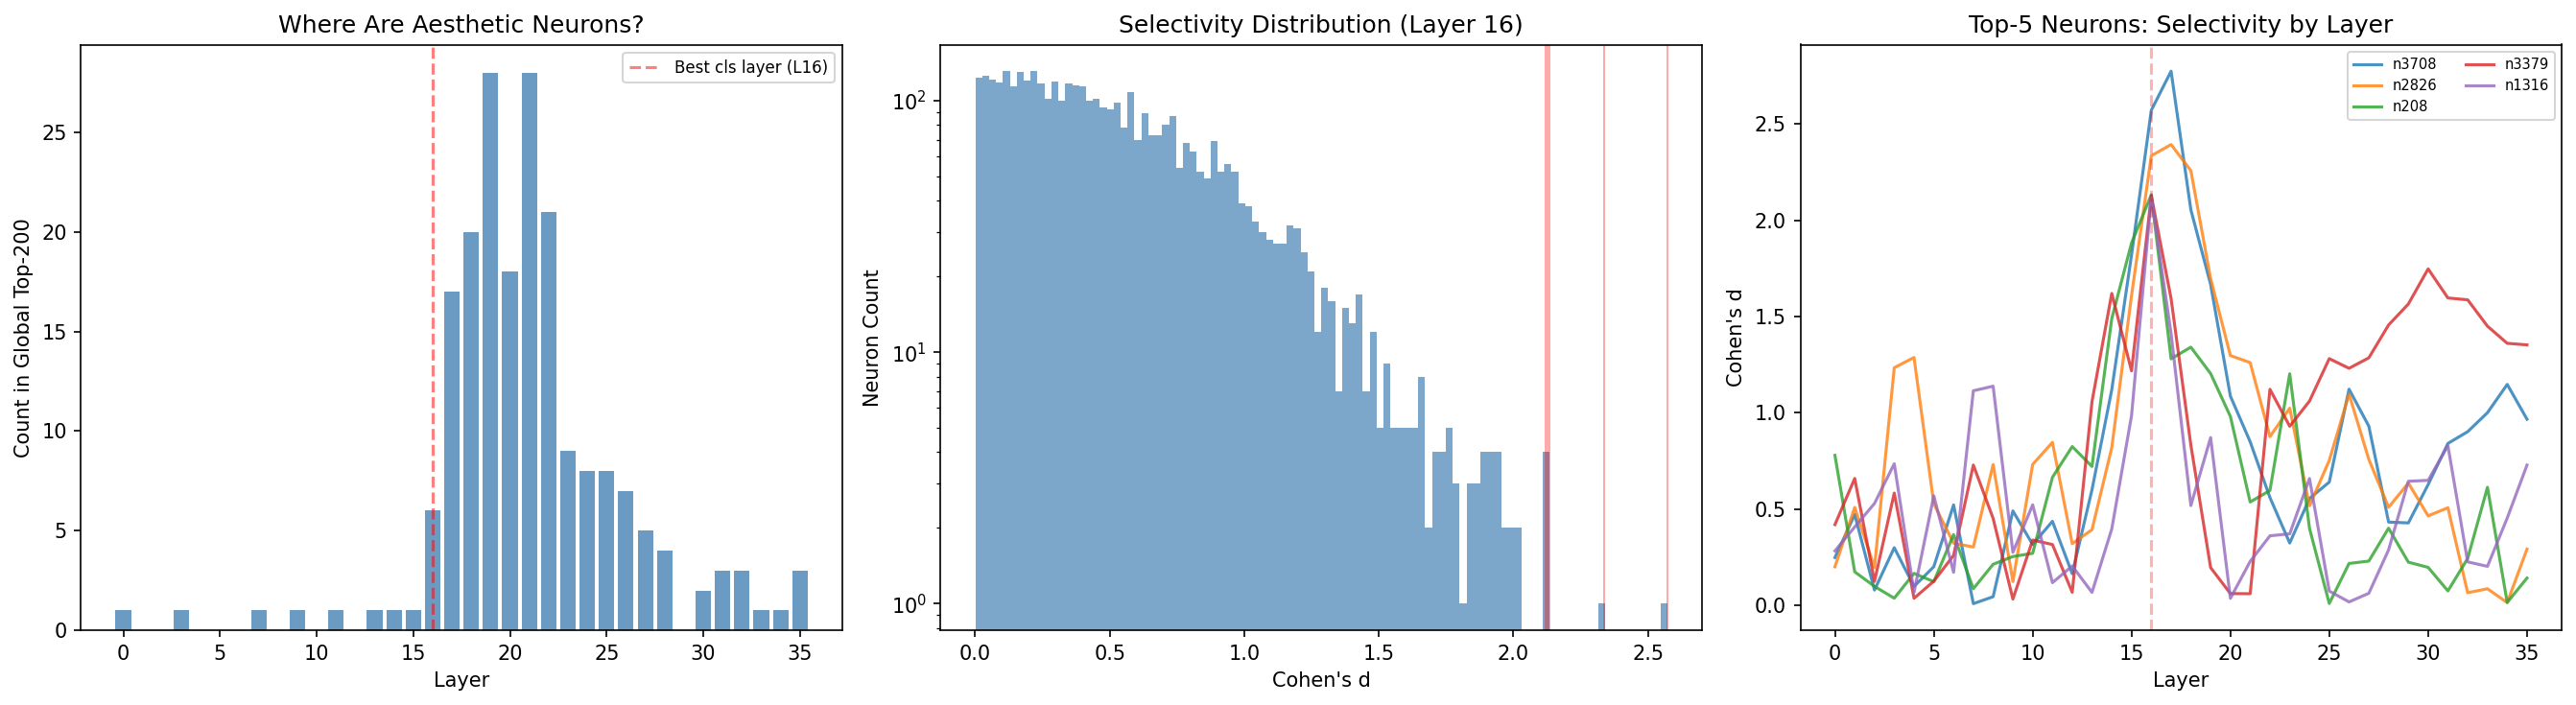

In [4]:
# Selectivity visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Where are the aesthetic neurons? Distribution of top-200 across layers
ax = axes[0]
top200 = np.unravel_index(np.argsort(selectivity.ravel())[-200:], selectivity.shape)
layer_hist = np.bincount(top200[0], minlength=N_LAYERS)
ax.bar(range(N_LAYERS), layer_hist, color='steelblue', alpha=0.8)
ax.set_xlabel('Layer'); ax.set_ylabel('Count in Global Top-200')
ax.set_title('Where Are Aesthetic Neurons?')
ax.axvline(best_layer, color='red', ls='--', alpha=0.5, label=f'Best cls layer (L{best_layer})')
ax.legend(fontsize=8)

# (b) Selectivity distribution at best layer
ax = axes[1]
sel_best = selectivity[best_layer]
ax.hist(sel_best, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
for v in np.sort(sel_best)[-5:]:
    ax.axvline(v, color='red', alpha=0.4, lw=0.8)
ax.set_xlabel("Cohen's d"); ax.set_ylabel('Neuron Count')
ax.set_title(f'Selectivity Distribution (Layer {best_layer})')
ax.set_yscale('log')

# (c) Top-5 neurons: selectivity across all layers
ax = axes[2]
for idx in top_sel[:5]:
    ax.plot(range(N_LAYERS), selectivity[:, idx], label=f'n{idx}', alpha=0.8)
ax.set_xlabel('Layer'); ax.set_ylabel("Cohen's d")
ax.set_title('Top-5 Neurons: Selectivity by Layer')
ax.legend(fontsize=7, ncol=2)
ax.axvline(best_layer, color='red', ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'selectivity_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## §4 Offline AUC Analysis

Before running the engine, we can predict ablation impact using saved Exp 2 activations. For each neuron $j$ at layer $L$: mask it (set to 0) → recompute projection onto aesthetic direction → measure AUC change.

In [5]:
# Per-neuron AUC drop at best layer (offline)
L = best_layer
p_L, n_L = pos_acts[:, L, :], neg_acts[:, L, :]  # (50, 4096) each
d_vec = aesthetic_dir_norm[L]                       # (4096,)

all_acts = np.concatenate([p_L, n_L], axis=0)  # (100, 4096)
labels = np.array([1]*N_POS + [0]*N_NEG)
base_proj = all_acts @ d_vec
base_auc = roc_auc_score(labels, base_proj)

# Vectorized: masked_proj_j = base_proj - acts[:, j] * d[j]
t0 = time.time()
neuron_auc = np.zeros(N_EMBD)
for j in range(N_EMBD):
    masked_proj = base_proj - all_acts[:, j] * d_vec[j]
    neuron_auc[j] = roc_auc_score(labels, masked_proj)
neuron_auc_drop = base_auc - neuron_auc

print(f'Per-neuron AUC computed in {time.time()-t0:.1f}s')
print(f'Baseline AUC: {base_auc:.4f}')
print(f'AUC drop: max={neuron_auc_drop.max():.4f}, neurons >0.01: {(neuron_auc_drop>0.01).sum()}, >0.05: {(neuron_auc_drop>0.05).sum()}')

# Top-10 by AUC drop
top_auc_neurons = np.argsort(neuron_auc_drop)[-20:][::-1]
print(f'\nTop-10 by AUC drop at L{L}:')
for r, j in enumerate(top_auc_neurons[:10]):
    print(f'  #{r+1}: n{j} — AUC drop={neuron_auc_drop[j]:.4f}, '
          f'selectivity={selectivity[L,j]:.2f}, dir_wt={direction_weight[L,j]:.4f}')

# ---------- Group ablation sweep (offline) ----------
group_sizes = [1, 5, 10, 20, 50, 100, 200, 500, 1000, 2048, 4096]
top_by_contrib = np.argsort(contribution[L])[::-1]

# Targeted
offline_targeted = []
for N in group_sizes:
    idx = top_by_contrib[:N]
    delta = (all_acts[:, idx] * d_vec[idx]).sum(axis=1)
    auc = roc_auc_score(labels, base_proj - delta)
    offline_targeted.append(auc)

# Random (20 seeds)
rng = np.random.RandomState(42)
offline_random_mean, offline_random_std = [], []
for N in group_sizes:
    aucs = []
    for _ in range(20):
        idx = rng.choice(N_EMBD, N, replace=False)
        delta = (all_acts[:, idx] * d_vec[idx]).sum(axis=1)
        aucs.append(roc_auc_score(labels, base_proj - delta))
    offline_random_mean.append(np.mean(aucs))
    offline_random_std.append(np.std(aucs))

print(f'\nOffline Group Ablation (Layer {L}):')
print(f'{"N":>6} {"Targeted":>10} {"Random":>16}')
for i, N in enumerate(group_sizes):
    print(f'{N:>6} {offline_targeted[i]:>10.4f} {offline_random_mean[i]:>10.4f} ± {offline_random_std[i]:.4f}')

Per-neuron AUC computed in 1.1s
Baseline AUC: 0.9992
AUC drop: max=0.0004, neurons >0.01: 0, >0.05: 0

Top-10 by AUC drop at L16:
  #1: n3179 — AUC drop=0.0004, selectivity=1.12, dir_wt=0.0663
  #2: n2276 — AUC drop=0.0004, selectivity=0.93, dir_wt=0.0827
  #3: n1350 — AUC drop=0.0004, selectivity=1.00, dir_wt=0.0345
  #4: n4095 — AUC drop=0.0000, selectivity=0.48, dir_wt=0.0092
  #5: n1366 — AUC drop=0.0000, selectivity=0.45, dir_wt=0.0094
  #6: n1362 — AUC drop=0.0000, selectivity=0.14, dir_wt=0.0027
  #7: n1363 — AUC drop=0.0000, selectivity=0.43, dir_wt=0.0126
  #8: n1364 — AUC drop=0.0000, selectivity=0.16, dir_wt=0.0033
  #9: n1365 — AUC drop=0.0000, selectivity=0.28, dir_wt=0.0080
  #10: n1368 — AUC drop=0.0000, selectivity=0.09, dir_wt=0.0032

Offline Group Ablation (Layer 16):
     N   Targeted           Random
     1     0.9992     0.9992 ± 0.0000
     5     0.9992     0.9992 ± 0.0000
    10     0.9992     0.9992 ± 0.0001
    20     0.9992     0.9991 ± 0.0001
    50     0.999

findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

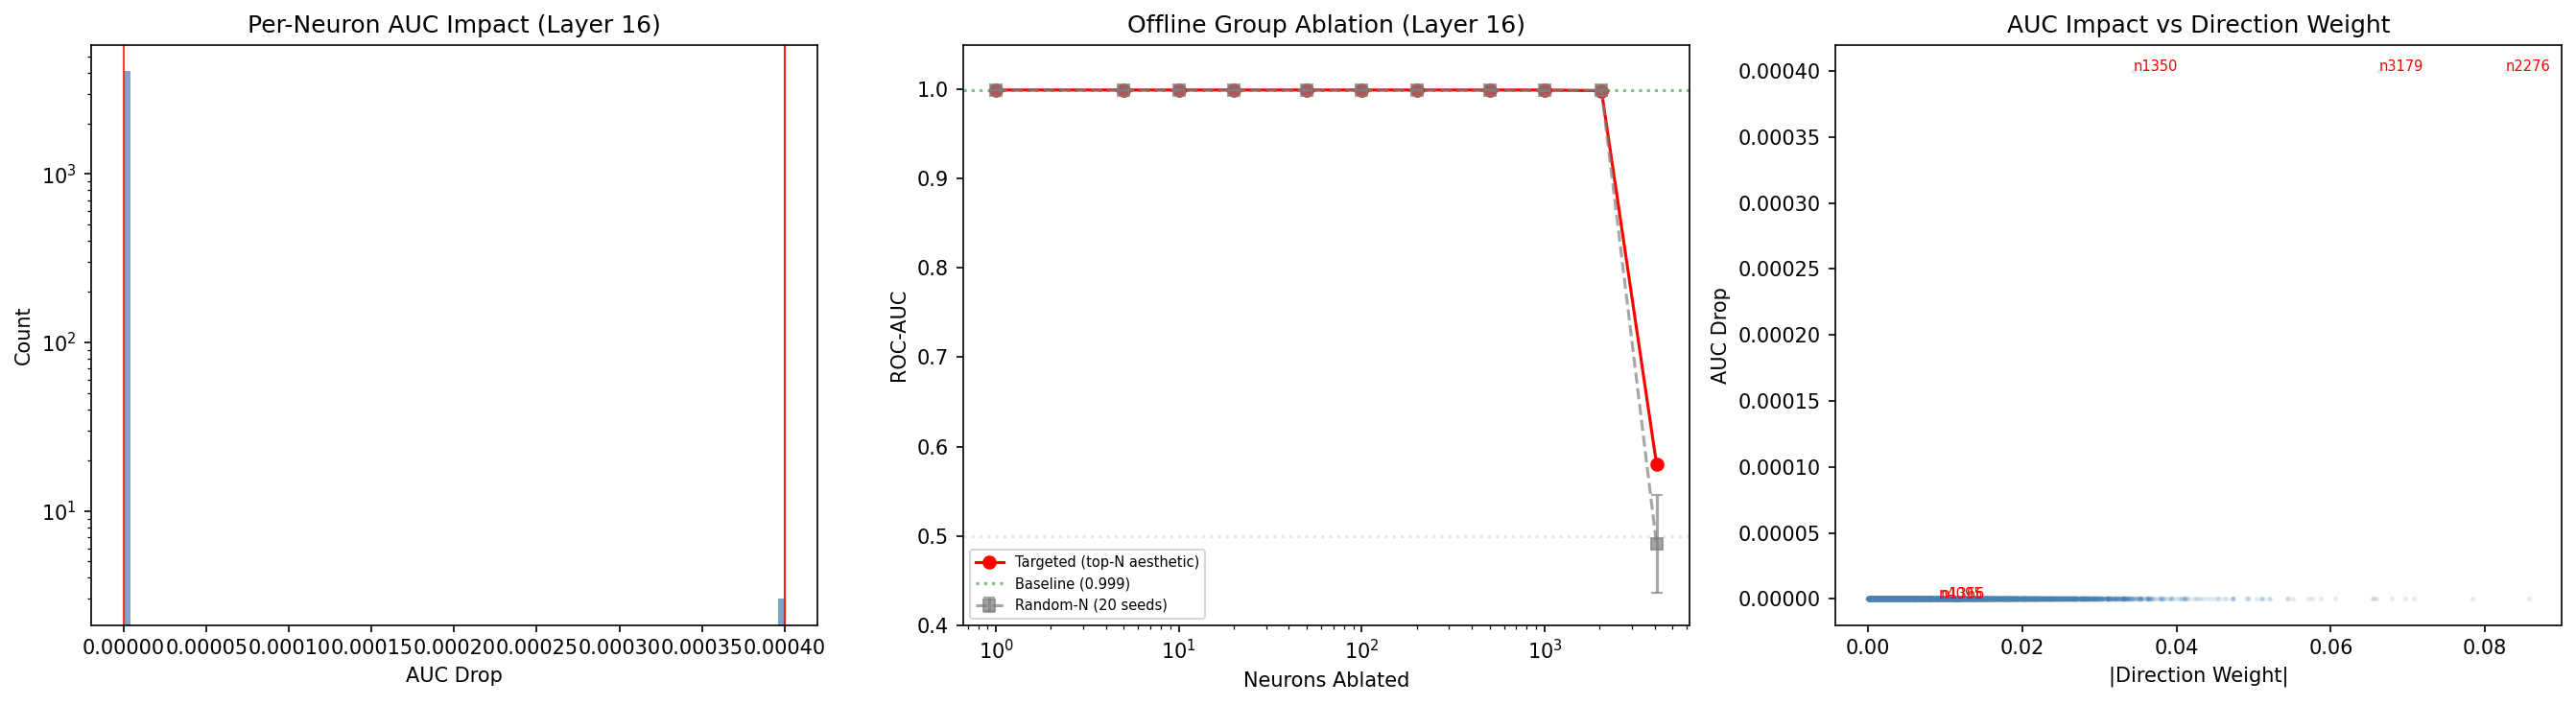

In [6]:
# Offline AUC visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Per-neuron AUC drop histogram
ax = axes[0]
ax.hist(neuron_auc_drop, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
for j in top_auc_neurons[:5]:
    ax.axvline(neuron_auc_drop[j], color='red', alpha=0.5, lw=1)
ax.set_xlabel('AUC Drop'); ax.set_ylabel('Count')
ax.set_title(f'Per-Neuron AUC Impact (Layer {best_layer})')
ax.set_yscale('log')

# (b) Group ablation: targeted vs random (offline)
ax = axes[1]
ax.plot(group_sizes, offline_targeted, 'o-', color='red', label='Targeted (top-N aesthetic)')
ax.errorbar(group_sizes, offline_random_mean, yerr=offline_random_std,
            fmt='s--', color='gray', alpha=0.7, label='Random-N (20 seeds)', capsize=3)
ax.axhline(base_auc, color='green', ls=':', alpha=0.5, label=f'Baseline ({base_auc:.3f})')
ax.axhline(0.5, color='gray', ls=':', alpha=0.2)
ax.set_xscale('log'); ax.set_xlabel('Neurons Ablated'); ax.set_ylabel('ROC-AUC')
ax.set_title(f'Offline Group Ablation (Layer {best_layer})')
ax.legend(fontsize=7); ax.set_ylim(0.4, 1.05)

# (c) AUC drop vs direction weight
ax = axes[2]
ax.scatter(direction_weight[best_layer], neuron_auc_drop, alpha=0.1, s=3, color='steelblue')
for j in top_auc_neurons[:5]:
    ax.annotate(f'n{j}', (direction_weight[best_layer, j], neuron_auc_drop[j]),
                fontsize=7, color='red')
ax.set_xlabel('|Direction Weight|'); ax.set_ylabel('AUC Drop')
ax.set_title('AUC Impact vs Direction Weight')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'offline_auc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## §5 Load Engine + Baseline Generation

Now we switch to **online ablation**: apply `engine.apply_mask()` during inference and measure how generated text changes.

In [7]:
# Load engine
engine = neuroscope.Engine(MODEL_PATH, n_ctx=4096, n_seq_max=1)
info = engine.model_info
print(f'Model: {info.name} ({info.n_layers}L, {info.n_embd}D)')

# Template test prompts
TEST_PROMPTS = []
for msg in TEST_PROMPTS_RAW:
    messages = [{'role': 'user', 'content': msg}]
    TEST_PROMPTS.append(engine.apply_chat_template(messages) + NOTHINK_SUFFIX)

# Baseline generation (no ablation)
print('\n--- Baseline Generation ---')
baseline_outputs = []
baseline_densities = []
t0 = time.time()
for i, prompt in enumerate(TEST_PROMPTS):
    engine.reset()
    output = engine.generate(prompt, max_tokens=128, temperature=0.0)
    density = aesthetic_density(output)
    awords = find_aesthetic_words(output)
    baseline_outputs.append(output)
    baseline_densities.append(density)
    print(f'  P{i+1}: density={density:.1f}%, words={awords}')
    print(f'       {output[:150]}...')

baseline_mean = np.mean(baseline_densities)
baseline_std = np.std(baseline_densities)
print(f'\nBaseline: {baseline_mean:.2f}% ± {baseline_std:.2f}% ({time.time()-t0:.1f}s)')

Model: Qwen3 8B Awq Compatible Instruct (36L, 4096D)

--- Baseline Generation ---
  P1: density=1.0%, words=['vibrant']
       In the gentle embrace of spring, a garden awakens from its winter slumber, bursting into a riot of color and life. The air is fresh, tinged with the s...
  P2: density=1.0%, words=['delicate']
       As the sun dips low, a golden whisper spills across the lake, painting its surface in hues of amber and rose. The water, still and glassy, mirrors the...
  P3: density=2.8%, words=['delicate', 'exquisite', 'harmonious']
       In the heart of a dimly lit gallery, nestled between towering glass cases and the hushed whispers of art enthusiasts, stands an exquisite piece of han...
  P4: density=0.0%, words=[]
       Imagine standing at the edge of a vast, shimmering lake, its surface so still it mirrors the sky like a polished mirror. The air is crisp and cool, ca...
  P5: density=0.0%, words=[]
       In the heart of a Japanese Zen garden, time seems to pause, and th

ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 109852028
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 109852028
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 107277 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           genera

## §6 Single-Neuron Ablation at Layer 16

Ablate the top-10 neurons (by offline AUC drop), one at a time. For each: apply mask → generate all 5 prompts → measure aesthetic density change.

In [8]:
TOP_N_SINGLE = 10
target_neurons = top_auc_neurons[:TOP_N_SINGLE]
L = best_layer

print(f'Ablating {TOP_N_SINGLE} neurons at Layer {L}, one at a time...')
single_results = {}
t0 = time.time()

for rank, nidx in enumerate(target_neurons):
    mask = np.ones(N_EMBD, dtype=np.float32)
    mask[nidx] = 0.0
    engine.apply_mask(L, mask)
    
    densities = []
    outputs = []
    for prompt in TEST_PROMPTS:
        engine.reset()
        out = engine.generate(prompt, max_tokens=128, temperature=0.0)
        densities.append(aesthetic_density(out))
        outputs.append(out)
    
    engine.clear_interventions()
    mean_d = np.mean(densities)
    single_results[int(nidx)] = {
        'densities': densities, 'outputs': outputs,
        'mean_density': mean_d,
        'density_change': mean_d - baseline_mean,
        'selectivity': float(selectivity[L, nidx]),
        'auc_drop_offline': float(neuron_auc_drop[nidx]),
    }
    pct = (mean_d - baseline_mean) / max(baseline_mean, 0.01) * 100
    print(f'  #{rank+1} n{nidx}: density={mean_d:.2f}% '
          f'(Δ={mean_d - baseline_mean:+.2f}%, {pct:+.1f}% relative)')

print(f'\nDone in {time.time()-t0:.1f}s')

Ablating 10 neurons at Layer 16, one at a time...
  #1 n3179: density=1.58% (Δ=+0.63%, +66.5% relative)
  #2 n2276: density=2.58% (Δ=+1.63%, +172.1% relative)
  #3 n1350: density=1.15% (Δ=+0.20%, +21.4% relative)
  #4 n4095: density=1.22% (Δ=+0.28%, +29.0% relative)
  #5 n1366: density=1.54% (Δ=+0.59%, +62.4% relative)
  #6 n1362: density=1.34% (Δ=+0.39%, +41.2% relative)
  #7 n1363: density=1.15% (Δ=+0.21%, +21.7% relative)
  #8 n1364: density=1.40% (Δ=+0.45%, +47.3% relative)
  #9 n1365: density=1.64% (Δ=+0.69%, +72.8% relative)
  #10 n1368: density=1.01% (Δ=+0.06%, +6.2% relative)

Done in 198.3s


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

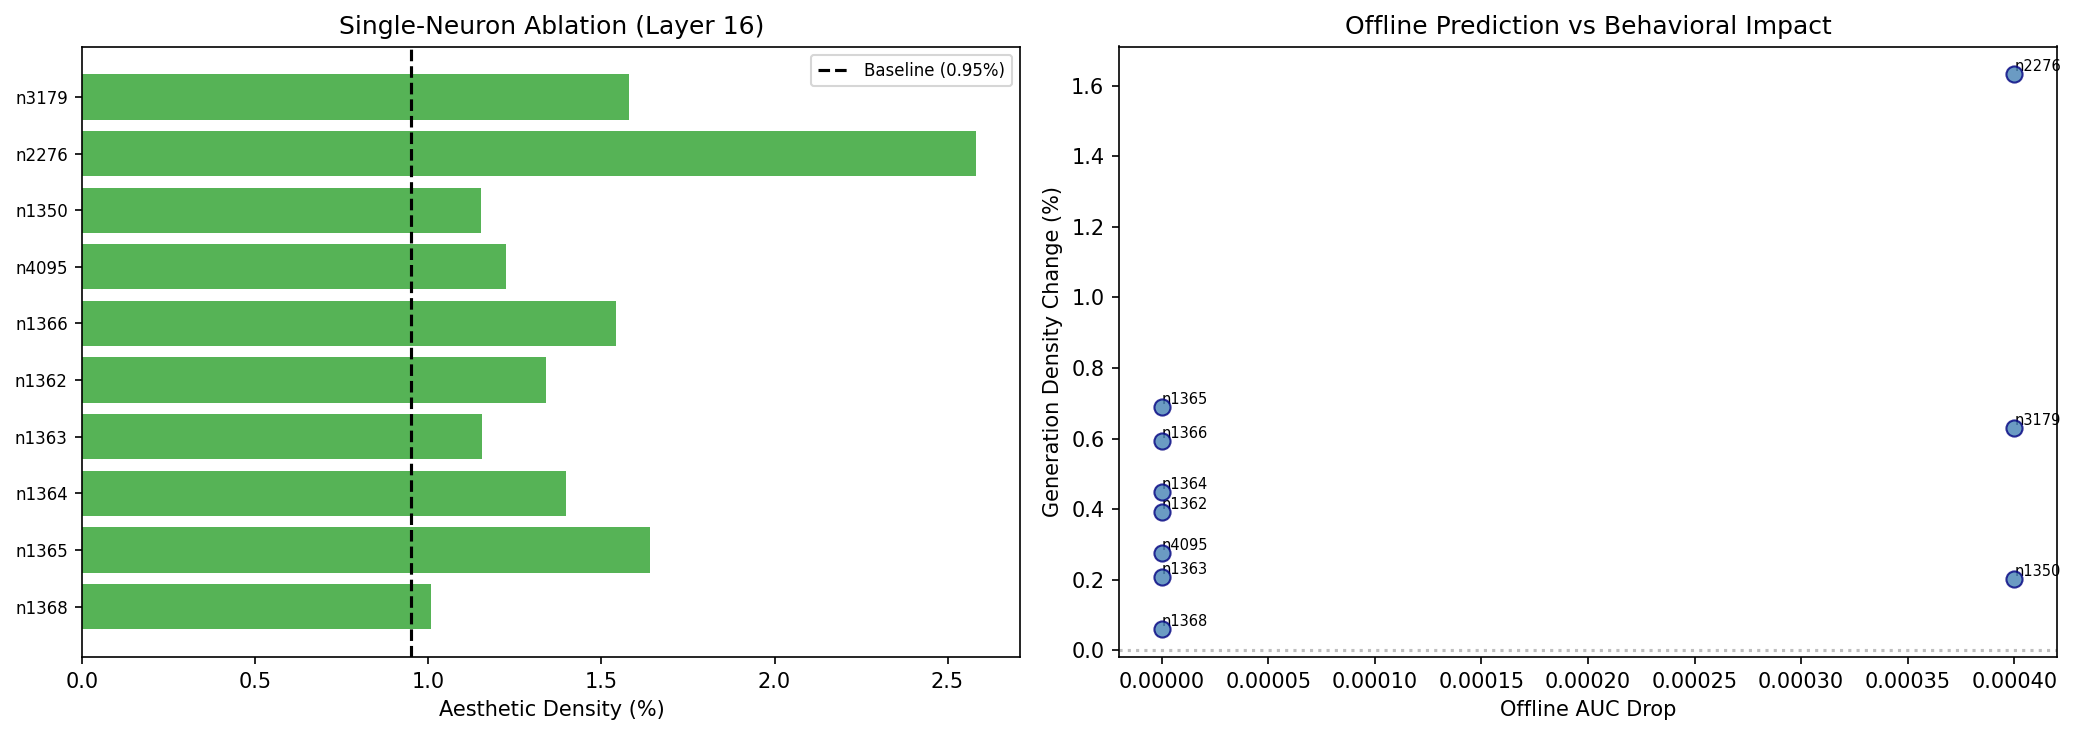

In [9]:
# Single-neuron visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neurons_list = list(single_results.keys())
means_list = [single_results[n]['mean_density'] for n in neurons_list]
changes_list = [single_results[n]['density_change'] for n in neurons_list]

# (a) Bar chart: density per neuron
ax = axes[0]
colors = ['#d62728' if m < baseline_mean else '#2ca02c' for m in means_list]
ax.barh(range(len(neurons_list)), means_list, color=colors, alpha=0.8)
ax.axvline(baseline_mean, color='black', ls='--', lw=1.5, label=f'Baseline ({baseline_mean:.2f}%)')
ax.set_yticks(range(len(neurons_list)))
ax.set_yticklabels([f'n{n}' for n in neurons_list], fontsize=8)
ax.set_xlabel('Aesthetic Density (%)')
ax.set_title(f'Single-Neuron Ablation (Layer {best_layer})')
ax.legend(fontsize=8); ax.invert_yaxis()

# (b) Offline prediction vs behavioral impact
ax = axes[1]
auc_drops_list = [single_results[n]['auc_drop_offline'] for n in neurons_list]
ax.scatter(auc_drops_list, changes_list, s=60, c='steelblue', edgecolors='navy', alpha=0.8, zorder=5)
for i, n in enumerate(neurons_list):
    ax.annotate(f'n{n}', (auc_drops_list[i], changes_list[i]),
                fontsize=7, ha='left', va='bottom')
ax.axhline(0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Offline AUC Drop')
ax.set_ylabel('Generation Density Change (%)')
ax.set_title('Offline Prediction vs Behavioral Impact')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'single_neuron_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## §7 Group Ablation Sweep: Finding the Tipping Point

Ablate the top-N most important neurons simultaneously. Is there a sharp **phase transition** where aesthetic capacity collapses? Compare with random ablation to prove specificity.

In [11]:
GROUP_SIZES = [5, 10, 20, 50, 100, 200, 500, 1000, 2048]
L = best_layer

# ------ Targeted ablation ------
print(f'=== Group ablation at Layer {L} ===')
print('\n--- Targeted (top-N by contribution) ---')
top_ranked = np.argsort(contribution[L])[::-1]
targeted_gen = {'sizes': [], 'densities': [], 'all_outputs': {}}

t0 = time.time()
for N in GROUP_SIZES:
    mask = np.ones(N_EMBD, dtype=np.float32)
    mask[top_ranked[:N]] = 0.0
    engine.apply_mask(L, mask)
    
    densities, outputs = [], []
    for prompt in TEST_PROMPTS:
        engine.reset()
        try:
            out = engine.generate(prompt, max_tokens=128, temperature=0.0)
        except (UnicodeDecodeError, RuntimeError):
            out = '[MODEL BROKEN]'
        densities.append(aesthetic_density(out))
        outputs.append(out)
    
    engine.clear_interventions()
    targeted_gen['sizes'].append(N)
    targeted_gen['densities'].append(np.mean(densities))
    targeted_gen['all_outputs'][N] = outputs
    pct = (np.mean(densities) - baseline_mean) / max(baseline_mean, 0.01) * 100
    print(f'  N={N:>5}: density={np.mean(densities):.2f}% ({pct:+.1f}%)')

print(f'  Done in {time.time()-t0:.1f}s')

# ------ Random control (2 seeds) ------
print('\n--- Random control (2 seeds) ---')
N_SEEDS = 2
rng_gen = np.random.RandomState(42)
random_gen = {'sizes': GROUP_SIZES, 'seed_densities': []}

t1 = time.time()
for N in GROUP_SIZES:
    seed_means = []
    for s in range(N_SEEDS):
        idx = rng_gen.choice(N_EMBD, N, replace=False)
        mask = np.ones(N_EMBD, dtype=np.float32)
        mask[idx] = 0.0
        engine.apply_mask(L, mask)
        
        densities = []
        for prompt in TEST_PROMPTS:
            engine.reset()
            try:
                out = engine.generate(prompt, max_tokens=128, temperature=0.0)
            except (UnicodeDecodeError, RuntimeError):
                out = '[MODEL BROKEN]'
            densities.append(aesthetic_density(out))
        
        engine.clear_interventions()
        seed_means.append(np.mean(densities))
    random_gen['seed_densities'].append(seed_means)
    m, s = np.mean(seed_means), np.std(seed_means)
    print(f'  N={N:>5}: density={m:.2f}% ± {s:.2f}%')

print(f'  Done in {time.time()-t1:.1f}s')

=== Group ablation at Layer 16 ===

--- Targeted (top-N by contribution) ---
  N=    5: density=1.93% (+103.8%)
  N=   10: density=2.68% (+182.7%)
  N=   20: density=2.78% (+193.1%)
  N=   50: density=2.71% (+185.6%)
  N=  100: density=2.56% (+169.9%)
  N=  200: density=3.05% (+221.3%)
  N=  500: density=2.34% (+147.1%)
  N= 1000: density=0.00% (-100.0%)
  N= 2048: density=0.00% (-100.0%)
  Done in 178.5s

--- Random control (2 seeds) ---
  N=    5: density=0.78% ± 0.01%
  N=   10: density=1.08% ± 0.09%
  N=   20: density=1.36% ± 0.05%
  N=   50: density=1.07% ± 0.07%
  N=  100: density=1.65% ± 0.85%
  N=  200: density=1.28% ± 0.32%
  N=  500: density=2.14% ± 0.31%
  N= 1000: density=1.93% ± 0.57%
  N= 2048: density=2.00% ± 2.00%
  Done in 358.0s


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

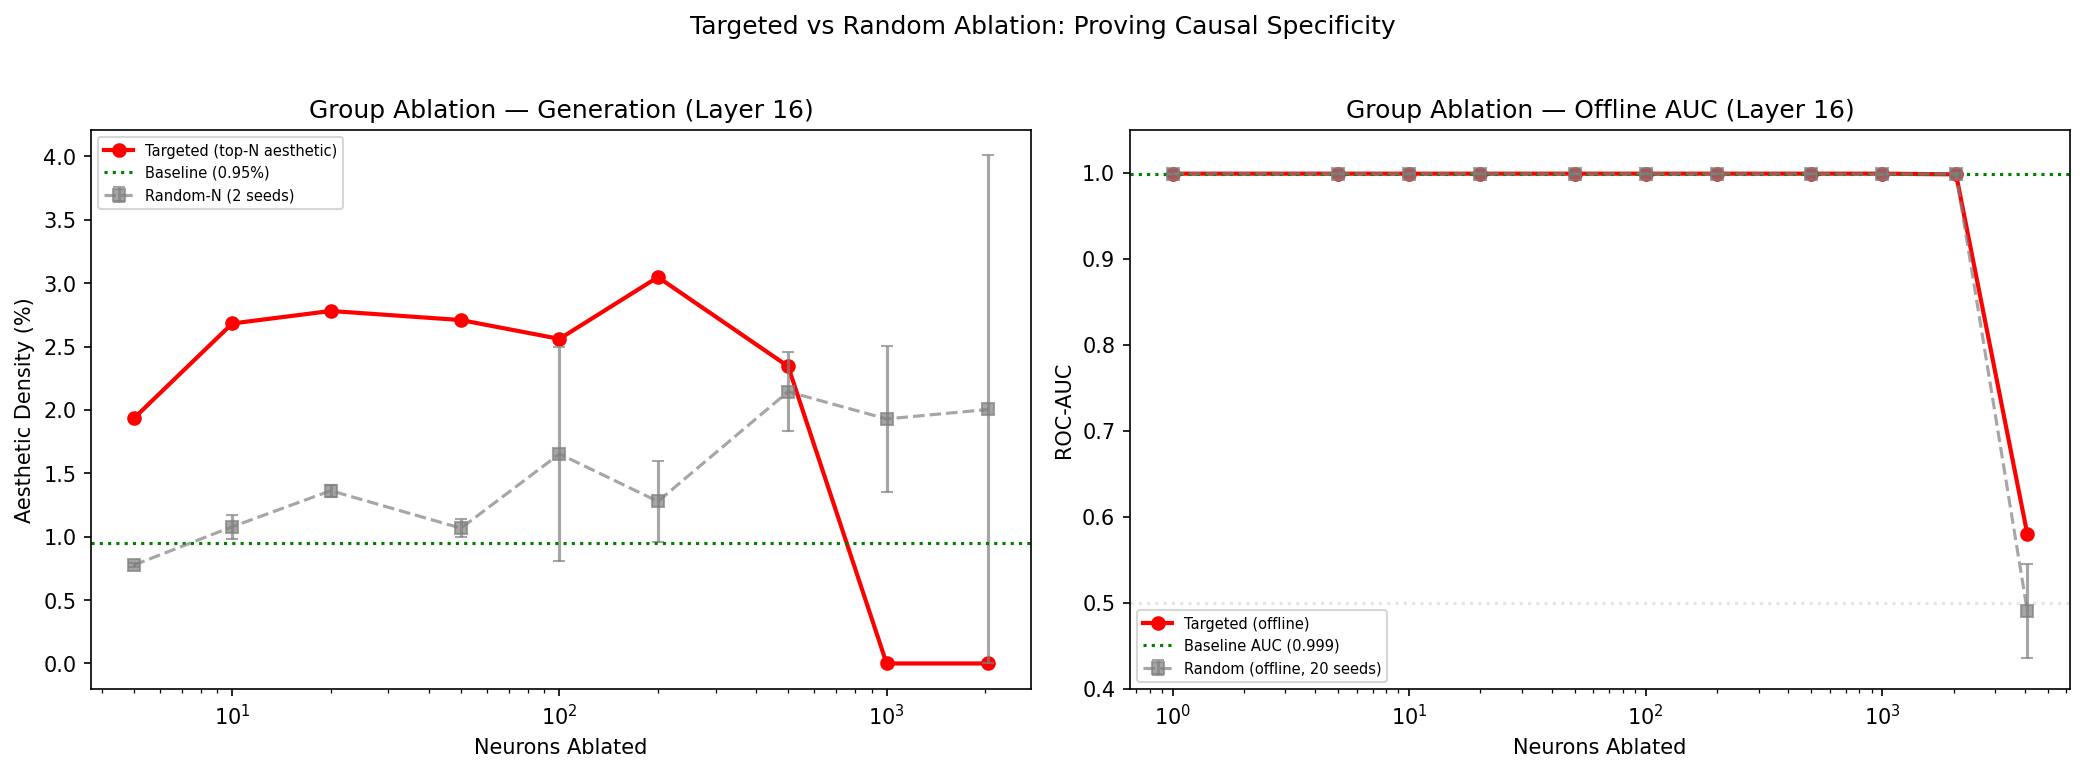

In [12]:
# Group ablation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

random_means = [np.mean(s) for s in random_gen['seed_densities']]
random_stds = [np.std(s) for s in random_gen['seed_densities']]

# (a) Generation-based: aesthetic density vs N ablated
ax = axes[0]
ax.plot(targeted_gen['sizes'], targeted_gen['densities'], 'o-', color='red',
        label='Targeted (top-N aesthetic)', lw=2, markersize=6)
ax.errorbar(GROUP_SIZES, random_means, yerr=random_stds,
            fmt='s--', color='gray', alpha=0.7, label=f'Random-N ({N_SEEDS} seeds)', capsize=3)
ax.axhline(baseline_mean, color='green', ls=':', lw=1.5, label=f'Baseline ({baseline_mean:.2f}%)')
ax.set_xscale('log')
ax.set_xlabel('Neurons Ablated')
ax.set_ylabel('Aesthetic Density (%)')
ax.set_title(f'Group Ablation — Generation (Layer {best_layer})')
ax.legend(fontsize=7)

# (b) Offline AUC comparison
ax = axes[1]
ax.plot(group_sizes, offline_targeted, 'o-', color='red', label='Targeted (offline)', lw=2)
ax.errorbar(group_sizes, offline_random_mean, yerr=offline_random_std,
            fmt='s--', color='gray', alpha=0.7, label='Random (offline, 20 seeds)', capsize=3)
ax.axhline(base_auc, color='green', ls=':', lw=1.5, label=f'Baseline AUC ({base_auc:.3f})')
ax.axhline(0.5, color='gray', ls=':', alpha=0.2)
ax.set_xscale('log')
ax.set_xlabel('Neurons Ablated')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Group Ablation — Offline AUC (Layer {best_layer})')
ax.legend(fontsize=7); ax.set_ylim(0.4, 1.05)

plt.suptitle('Targeted vs Random Ablation: Proving Causal Specificity', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'group_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## §8 Layer Sensitivity

Which layers are most vulnerable? Ablate the top-20 aesthetic neurons at each layer and measure generation impact.

In [13]:
N_ABLATE_LAYER = 20
print(f'Layer sensitivity: ablate top-{N_ABLATE_LAYER} at each of {len(ABLATION_LAYERS)} layers')
layer_results = {'layers': [], 'densities': [], 'outputs': {}}

t0 = time.time()
for L in ABLATION_LAYERS:
    top_at_L = np.argsort(contribution[L])[-N_ABLATE_LAYER:]
    mask = np.ones(N_EMBD, dtype=np.float32)
    mask[top_at_L] = 0.0
    engine.apply_mask(L, mask)
    
    densities, outputs = [], []
    for prompt in TEST_PROMPTS:
        engine.reset()
        try:
            out = engine.generate(prompt, max_tokens=128, temperature=0.0)
        except (UnicodeDecodeError, RuntimeError):
            out = '[MODEL BROKEN]'
        densities.append(aesthetic_density(out))
        outputs.append(out)
    
    engine.clear_interventions()
    layer_results['layers'].append(L)
    layer_results['densities'].append(np.mean(densities))
    layer_results['outputs'][L] = outputs
    pct = (np.mean(densities) - baseline_mean) / max(baseline_mean, 0.01) * 100
    print(f'  L{L:>2}: density={np.mean(densities):.2f}% ({pct:+.1f}%)')

print(f'\nDone in {time.time()-t0:.1f}s')

# Most sensitive layer
min_idx = np.argmin(layer_results['densities'])
most_sensitive = layer_results['layers'][min_idx]
print(f'Most sensitive layer: L{most_sensitive} '
      f'(density={layer_results["densities"][min_idx]:.2f}%)')

Layer sensitivity: ablate top-20 at each of 10 layers
  L 0: density=0.99% (+4.6%)
  L 3: density=1.20% (+26.1%)
  L 8: density=1.93% (+103.0%)
  L12: density=1.35% (+42.1%)
  L16: density=2.78% (+193.1%)
  L20: density=1.51% (+59.6%)
  L24: density=1.54% (+62.5%)
  L28: density=1.19% (+25.2%)
  L32: density=0.83% (-12.4%)
  L35: density=0.57% (-40.1%)

Done in 199.0s
Most sensitive layer: L35 (density=0.57%)


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

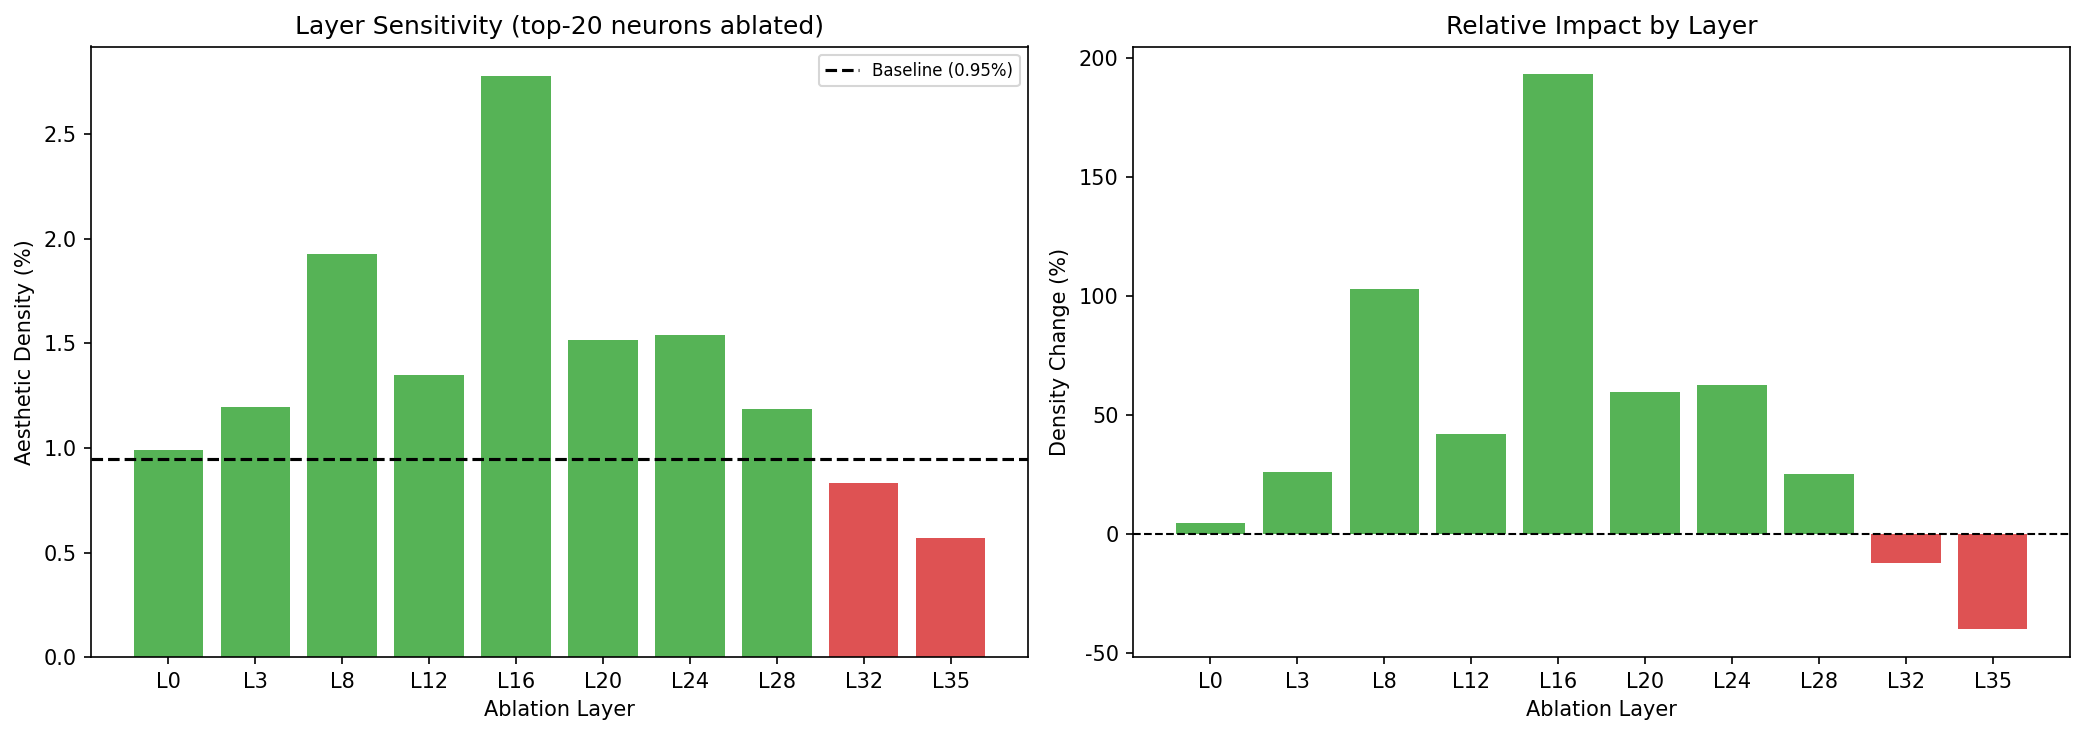

In [14]:
# Layer sensitivity visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Bar chart: density by layer
ax = axes[0]
colors_layer = ['#d62728' if d < baseline_mean * 0.9 else
                '#ff7f0e' if d < baseline_mean else '#2ca02c'
                for d in layer_results['densities']]
bars = ax.bar(range(len(ABLATION_LAYERS)), layer_results['densities'],
              color=colors_layer, alpha=0.8)
ax.axhline(baseline_mean, color='black', ls='--', lw=1.5, label=f'Baseline ({baseline_mean:.2f}%)')
ax.set_xticks(range(len(ABLATION_LAYERS)))
ax.set_xticklabels([f'L{l}' for l in ABLATION_LAYERS])
ax.set_xlabel('Ablation Layer')
ax.set_ylabel('Aesthetic Density (%)')
ax.set_title(f'Layer Sensitivity (top-{N_ABLATE_LAYER} neurons ablated)')
ax.legend(fontsize=8)

# (b) Overlay with Exp2/Exp3 emergence curves
ax = axes[1]
pct_change = [(d - baseline_mean) / max(baseline_mean, 0.01) * 100
              for d in layer_results['densities']]
ax.bar(range(len(ABLATION_LAYERS)), pct_change, color=colors_layer, alpha=0.8)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_xticks(range(len(ABLATION_LAYERS)))
ax.set_xticklabels([f'L{l}' for l in ABLATION_LAYERS])
ax.set_xlabel('Ablation Layer')
ax.set_ylabel('Density Change (%)')
ax.set_title('Relative Impact by Layer')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'layer_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## §9 Qualitative Text Comparison

Compare generated text: baseline vs single-neuron ablation vs heavy group ablation.

In [15]:
# Show text comparison for prompt 1
P = 0  # first prompt
print(f'Prompt: "{TEST_PROMPTS_RAW[P][:80]}..."')
print(f'\n{"="*80}')
print(f'BASELINE (density={baseline_densities[P]:.1f}%):')
print(baseline_outputs[P][:400])

# Most impactful single neuron
most_impactful = min(single_results.items(), key=lambda x: x[1]['mean_density'])
nidx, sdata = most_impactful
print(f'\n{"="*80}')
print(f'ABLATE n{nidx} at L{best_layer} (density={sdata["densities"][P]:.1f}%):')
print(sdata['outputs'][P][:400])

# Heavy group ablation (largest N)
largest_N = targeted_gen['sizes'][-1]
print(f'\n{"="*80}')
print(f'ABLATE top-{largest_N} at L{best_layer} '
      f'(density={targeted_gen["densities"][-1]:.1f}%):')
print(targeted_gen['all_outputs'][largest_N][P][:400])

# Most sensitive layer
print(f'\n{"="*80}')
print(f'ABLATE top-{N_ABLATE_LAYER} at most sensitive L{most_sensitive} '
      f'(density={layer_results["densities"][min_idx]:.1f}%):')
print(layer_results['outputs'][most_sensitive][P][:400])

Prompt: "Describe the beauty of a garden in spring, with flowers blooming and butterflies..."

BASELINE (density=1.0%):
In the gentle embrace of spring, a garden awakens from its winter slumber, bursting into a riot of color and life. The air is fresh, tinged with the sweet scent of blooming flowers, and the sun casts a warm, golden glow over the landscape. Petals unfurl like whispers of poetry, each blossom a masterpiece in nature’s hand—roses blush with soft pink, daffodils gleam in sunny yellows, and tulips stan

ABLATE n1368 at L16 (density=1.0%):
In the gentle embrace of spring, a garden awakens from its winter slumber, bursting into a riot of color and life. The air is fresh, tinged with the sweet scent of blooming flowers, and the sun casts a warm, golden glow over the landscape. Petals unfurl like whispers of poetry, each blossom a masterpiece in nature’s hand—roses blush with soft pink, daffodils gleam in sunny yellows, and tulips stan

ABLATE top-2048 at L16 (density=0.0%):
 

## §10 Summary & Save Results

In [16]:
# Save all results
np.savez(OUTPUT_DIR / 'ablation_results.npz',
    # Selectivity scores
    selectivity=selectivity,
    contribution=contribution,
    direction_weight=direction_weight,
    neuron_auc_drop=neuron_auc_drop,
    # Single-neuron
    single_neurons=np.array(list(single_results.keys())),
    single_densities=np.array([single_results[n]['mean_density'] for n in single_results]),
    single_changes=np.array([single_results[n]['density_change'] for n in single_results]),
    # Group ablation (generation)
    group_sizes_gen=np.array(targeted_gen['sizes']),
    group_targeted_gen=np.array(targeted_gen['densities']),
    group_random_gen=np.array([np.mean(s) for s in random_gen['seed_densities']]),
    group_random_gen_std=np.array([np.std(s) for s in random_gen['seed_densities']]),
    # Group ablation (offline)
    group_sizes_offline=np.array(group_sizes),
    group_targeted_offline=np.array(offline_targeted),
    group_random_offline_mean=np.array(offline_random_mean),
    group_random_offline_std=np.array(offline_random_std),
    # Layer sensitivity
    layer_sweep=np.array(layer_results['layers']),
    layer_densities=np.array(layer_results['densities']),
    # Meta
    best_layer=best_layer,
    baseline_mean=baseline_mean,
    baseline_std=baseline_std,
)
print(f'Results saved to {OUTPUT_DIR}')

# ==============================================================
print('\n' + '='*65)
print('EXPERIMENT 5 SUMMARY: Aesthetic Neurons via Ablation')
print('='*65)
print(f'Model: Qwen3-8B Q4_K_M ({N_LAYERS} layers, {N_EMBD} dim)')
print(f'Best classification layer: {best_layer}')
print(f'Baseline aesthetic density: {baseline_mean:.2f}% ± {baseline_std:.2f}%')
print()

print('--- Neuron Selectivity ---')
print(f'  Max Cohen\'s d at L{best_layer}: {selectivity[best_layer].max():.3f}')
print(f'  Top neuron by AUC drop: n{top_auc_neurons[0]} '
      f'(drop={neuron_auc_drop[top_auc_neurons[0]]:.4f})')

print(f'\n--- Single-Neuron Ablation (L{best_layer}) ---')
for n in list(single_results.keys())[:5]:
    sr = single_results[n]
    print(f'  n{n}: {sr["mean_density"]:.2f}% '
          f'(Δ={sr["density_change"]:+.2f}%)')

print(f'\n--- Group Ablation (L{best_layer}) ---')
for i, N in enumerate(targeted_gen['sizes']):
    pct = (targeted_gen['densities'][i] - baseline_mean) / max(baseline_mean, 0.01) * 100
    print(f'  Top-{N:>5}: {targeted_gen["densities"][i]:.2f}% ({pct:+.1f}% vs baseline)')

print(f'\n--- Layer Sensitivity (top-{N_ABLATE_LAYER} ablated) ---')
for i, L in enumerate(layer_results['layers']):
    pct = (layer_results['densities'][i] - baseline_mean) / max(baseline_mean, 0.01) * 100
    marker = ' ← most sensitive' if L == most_sensitive else ''
    print(f'  L{L:>2}: {layer_results["densities"][i]:.2f}% ({pct:+.1f}%){marker}')

print(f'\n--- Offline Group AUC (L{best_layer}) ---')
for i, N in enumerate(group_sizes):
    print(f'  Top-{N:>5}: AUC={offline_targeted[i]:.4f} '
          f'(random={offline_random_mean[i]:.4f}±{offline_random_std[i]:.4f})')

print(f'\nResults saved to: {OUTPUT_DIR}')
print('='*65)

Results saved to /workspace/Data/aesthetic_neurons

EXPERIMENT 5 SUMMARY: Aesthetic Neurons via Ablation
Model: Qwen3-8B Q4_K_M (36 layers, 4096 dim)
Best classification layer: 16
Baseline aesthetic density: 0.95% ± 1.01%

--- Neuron Selectivity ---
  Max Cohen's d at L16: 2.572
  Top neuron by AUC drop: n3179 (drop=0.0004)

--- Single-Neuron Ablation (L16) ---
  n3179: 1.58% (Δ=+0.63%)
  n2276: 2.58% (Δ=+1.63%)
  n1350: 1.15% (Δ=+0.20%)
  n4095: 1.22% (Δ=+0.28%)
  n1366: 1.54% (Δ=+0.59%)

--- Group Ablation (L16) ---
  Top-    5: 1.93% (+103.8% vs baseline)
  Top-   10: 2.68% (+182.7% vs baseline)
  Top-   20: 2.78% (+193.1% vs baseline)
  Top-   50: 2.71% (+185.6% vs baseline)
  Top-  100: 2.56% (+169.9% vs baseline)
  Top-  200: 3.05% (+221.3% vs baseline)
  Top-  500: 2.34% (+147.1% vs baseline)
  Top- 1000: 0.00% (-100.0% vs baseline)
  Top- 2048: 0.00% (-100.0% vs baseline)

--- Layer Sensitivity (top-20 ablated) ---
  L 0: 0.99% (+4.6%)
  L 3: 1.20% (+26.1%)
  L 8: 1.93% (+103.0

In [17]:
engine.reset()
print('Engine reset. Ready for next experiment.')

Engine reset. Ready for next experiment.


## §12 Cross-Lingual Aesthetic Steering

Decompose aesthetic neurons into **Universal Set** + **Per-Language Sets**, then transplant aesthetic sensibility:
suppress language A's specific neurons + activate language B's specific neurons.

In [27]:
# === S12a: Build Neuron Sets — Universal + Per-Language ===
import numpy as np

# ---------- thresholds ----------
UNIVERSAL_TOP_PCT   = 10   # top 10% mean selectivity
UNIVERSAL_CV_BELOW  = 50   # CV below median
SPECIFIC_HIGH_PCT   = 80   # high selectivity for own language
SPECIFIC_LOW_PCT    = 50   # low selectivity for other languages
STEER_STRENGTH      = 5.0

# ---------- Universal set ----------
mean_thresh = np.percentile(mean_sel, 100 - UNIVERSAL_TOP_PCT)
cv_thresh   = np.percentile(cv_sel, UNIVERSAL_CV_BELOW)
universal_set = np.where((mean_sel >= mean_thresh) & (cv_sel <= cv_thresh))[0]
universal_set_s = set(universal_set.tolist())
print(f'Universal aesthetic neurons: {len(universal_set)}')
print(f'  mean |d| >= {mean_thresh:.3f}, CV <= {cv_thresh:.3f}')

# ---------- Per-language specific sets ----------
lang_specific_sets = {}
lang_steering_vecs = {}
for li, lang in enumerate(LANGS):
    own_sel = sel_matrix[li]
    others  = np.delete(sel_matrix, li, axis=0)
    max_other = others.max(axis=0)
    high_own  = np.percentile(own_sel, SPECIFIC_HIGH_PCT)
    low_other = np.percentile(max_other, SPECIFIC_LOW_PCT)
    specific_idx = np.where((own_sel >= high_own) & (max_other <= low_other))[0]
    # Remove universal neurons from specific sets
    specific_idx = np.array([n for n in specific_idx if n not in universal_set_s])
    lang_specific_sets[lang] = specific_idx
    # Steering vector: signed direction at best_layer, masked to specific neurons
    raw_dir = direction_by_lang[lang][best_layer]
    steer = np.zeros(N_EMBD, dtype=np.float32)
    if len(specific_idx) > 0:
        steer[specific_idx] = raw_dir[specific_idx]
    lang_steering_vecs[lang] = steer
    print(f'  {lang}: {len(specific_idx):4d} specific neurons, steer norm={np.linalg.norm(steer):.3f}')

# Universal steering vector (average direction, masked to universal set)
universal_vec = np.zeros(N_EMBD, dtype=np.float32)
for lang in LANGS:
    universal_vec += direction_by_lang[lang][best_layer]
universal_vec /= len(LANGS)
umask = np.zeros(N_EMBD, dtype=np.float32)
umask[universal_set] = 1.0
universal_vec *= umask
print(f'  Universal steer norm: {np.linalg.norm(universal_vec):.3f}')

# ---------- Pairwise Jaccard ----------
print(f'\n--- Pairwise Jaccard (specific sets) ---')
jaccard_specific = np.zeros((len(LANGS), len(LANGS)))
for i, l1 in enumerate(LANGS):
    s1 = set(lang_specific_sets[l1].tolist())
    for j, l2 in enumerate(LANGS):
        s2 = set(lang_specific_sets[l2].tolist())
        union = len(s1 | s2)
        jaccard_specific[i, j] = len(s1 & s2) / union if union > 0 else 0
        if j > i:
            print(f'  {l1}-{l2}: J={jaccard_specific[i,j]:.3f} (overlap {len(s1&s2)}, union {union})')

# helper used in S12c
def aesthetic_density(text):
    words = text.lower().split()
    if len(words) == 0: return 0.0
    return 100.0 * sum(1 for w in words if w.strip('.,!?;:') in AESTHETIC_WORDS) / len(words)

print(f'\n§12a done — {len(universal_set)} universal + '
      f'{sum(len(v) for v in lang_specific_sets.values())} total specific neurons')


Universal aesthetic neurons: 356
  mean |d| >= 1.390, CV <= 0.566
  EN:  285 specific neurons, steer norm=4.491
  ZH:  295 specific neurons, steer norm=6.183
  JA:  247 specific neurons, steer norm=3.785
  FR:  219 specific neurons, steer norm=2.440
  ES:  223 specific neurons, steer norm=2.422
  Universal steer norm: 5.374

--- Pairwise Jaccard (specific sets) ---
  EN-ZH: J=0.000 (overlap 0, union 580)
  EN-JA: J=0.000 (overlap 0, union 532)
  EN-FR: J=0.035 (overlap 17, union 487)
  EN-ES: J=0.024 (overlap 12, union 496)
  ZH-JA: J=0.000 (overlap 0, union 542)
  ZH-FR: J=0.000 (overlap 0, union 514)
  ZH-ES: J=0.000 (overlap 0, union 518)
  JA-FR: J=0.000 (overlap 0, union 466)
  JA-ES: J=0.000 (overlap 0, union 470)
  FR-ES: J=0.097 (overlap 39, union 403)

§12a done — 356 universal + 1269 total specific neurons


In [28]:
# === S12b: Cross-Lingual Aesthetic Steering Experiment ===
# For a prompt in language A, suppress A's specific neurons and activate B's.
#
# Method: engine.apply_steering(layer, -lang_A_vec, strength) to suppress
#         engine.apply_steering(layer, +lang_B_vec, strength) to activate

STEER_STRENGTH = 5.0
MAX_TOKENS = 200

# Test prompts in different languages asking for aesthetic description
CROSS_PROMPTS = {
    'EN': 'Describe the beauty of a garden in spring.',
    'ZH': 'Please describe the beauty of a spring garden, in Chinese.',
    'JA': 'Please describe the beauty of a spring garden, in Japanese.',
    'FR': 'Please describe the beauty of a spring garden, in French.',
    'ES': 'Please describe the beauty of a spring garden, in Spanish.',
}

# Steering pairs: (source_lang, target_lang) -- write in source, aesthetic of target
STEER_PAIRS = [
    ('EN', 'ZH'),   # English text, Chinese aesthetic
    ('EN', 'JA'),   # English text, Japanese aesthetic
    ('ZH', 'EN'),   # Chinese text, English aesthetic
    ('ZH', 'JA'),   # Chinese text, Japanese aesthetic
    ('JA', 'ZH'),   # Japanese text, Chinese aesthetic
    ('FR', 'JA'),   # French text, Japanese aesthetic
]

results = {}

for src, tgt in STEER_PAIRS:
    print(f'\n{"="*60}')
    print(f'  Steering: {src} text + {tgt} aesthetic (strength={STEER_STRENGTH})')
    print(f'{"="*60}')
    
    prompt_text = CROSS_PROMPTS[src]
    messages = [{'role': 'user', 'content': prompt_text}]
    templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX
    
    # --- Baseline (no steering) ---
    engine.reset()
    engine.clear_interventions()
    out_base = engine.generate(templated, max_tokens=MAX_TOKENS, temperature=0.0)
    
    # --- Steered: suppress src aesthetic + activate tgt aesthetic ---
    engine.reset()
    engine.clear_interventions()
    # Suppress source language's specific aesthetic neurons
    engine.apply_steering(best_layer, -lang_steering_vecs[src].astype(np.float32), float(STEER_STRENGTH))
    # Activate target language's specific aesthetic neurons
    engine.apply_steering(best_layer, lang_steering_vecs[tgt].astype(np.float32), float(STEER_STRENGTH))
    try:
        out_steered = engine.generate(templated, max_tokens=MAX_TOKENS, temperature=0.0)
    except Exception as e:
        out_steered = f'[ERROR: {e}]'
    
    engine.clear_interventions()
    
    results[(src, tgt)] = {'baseline': out_base, 'steered': out_steered}
    
    print(f'\n  [Baseline {src}]:')
    print(f'    {out_base[:300]}')
    print(f'\n  [Steered {src}+{tgt} aesthetic]:')
    print(f'    {out_steered[:300]}')


  Steering: EN text + ZH aesthetic (strength=5.0)

  [Baseline EN]:
    In the gentle embrace of spring, a garden awakens from its winter slumber, bursting with life and color. The air is fresh, carrying the sweet scent of blooming flowers and the earthy fragrance of damp soil. Sunlight filters through the trees, casting dappled patterns on the ground, while a gentle br

  [Steered EN+ZH aesthetic]:
    In the gentle embrace of spring, a garden awakens from its winter slumber, bursting with life and color. The air is fresh and fragrant, carrying the sweet scent of blooming flowers and the earthy aroma of damp soil. Sunlight filters through the canopy of trees, casting dappled shadows on the soft, g

  Steering: EN text + JA aesthetic (strength=5.0)

  [Baseline EN]:
    In the gentle embrace of spring, a garden awakens from its winter slumber, bursting with life and color. The air is fresh, carrying the sweet scent of blooming flowers and the earthy fragrance of damp soil. Sunlight fi

findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

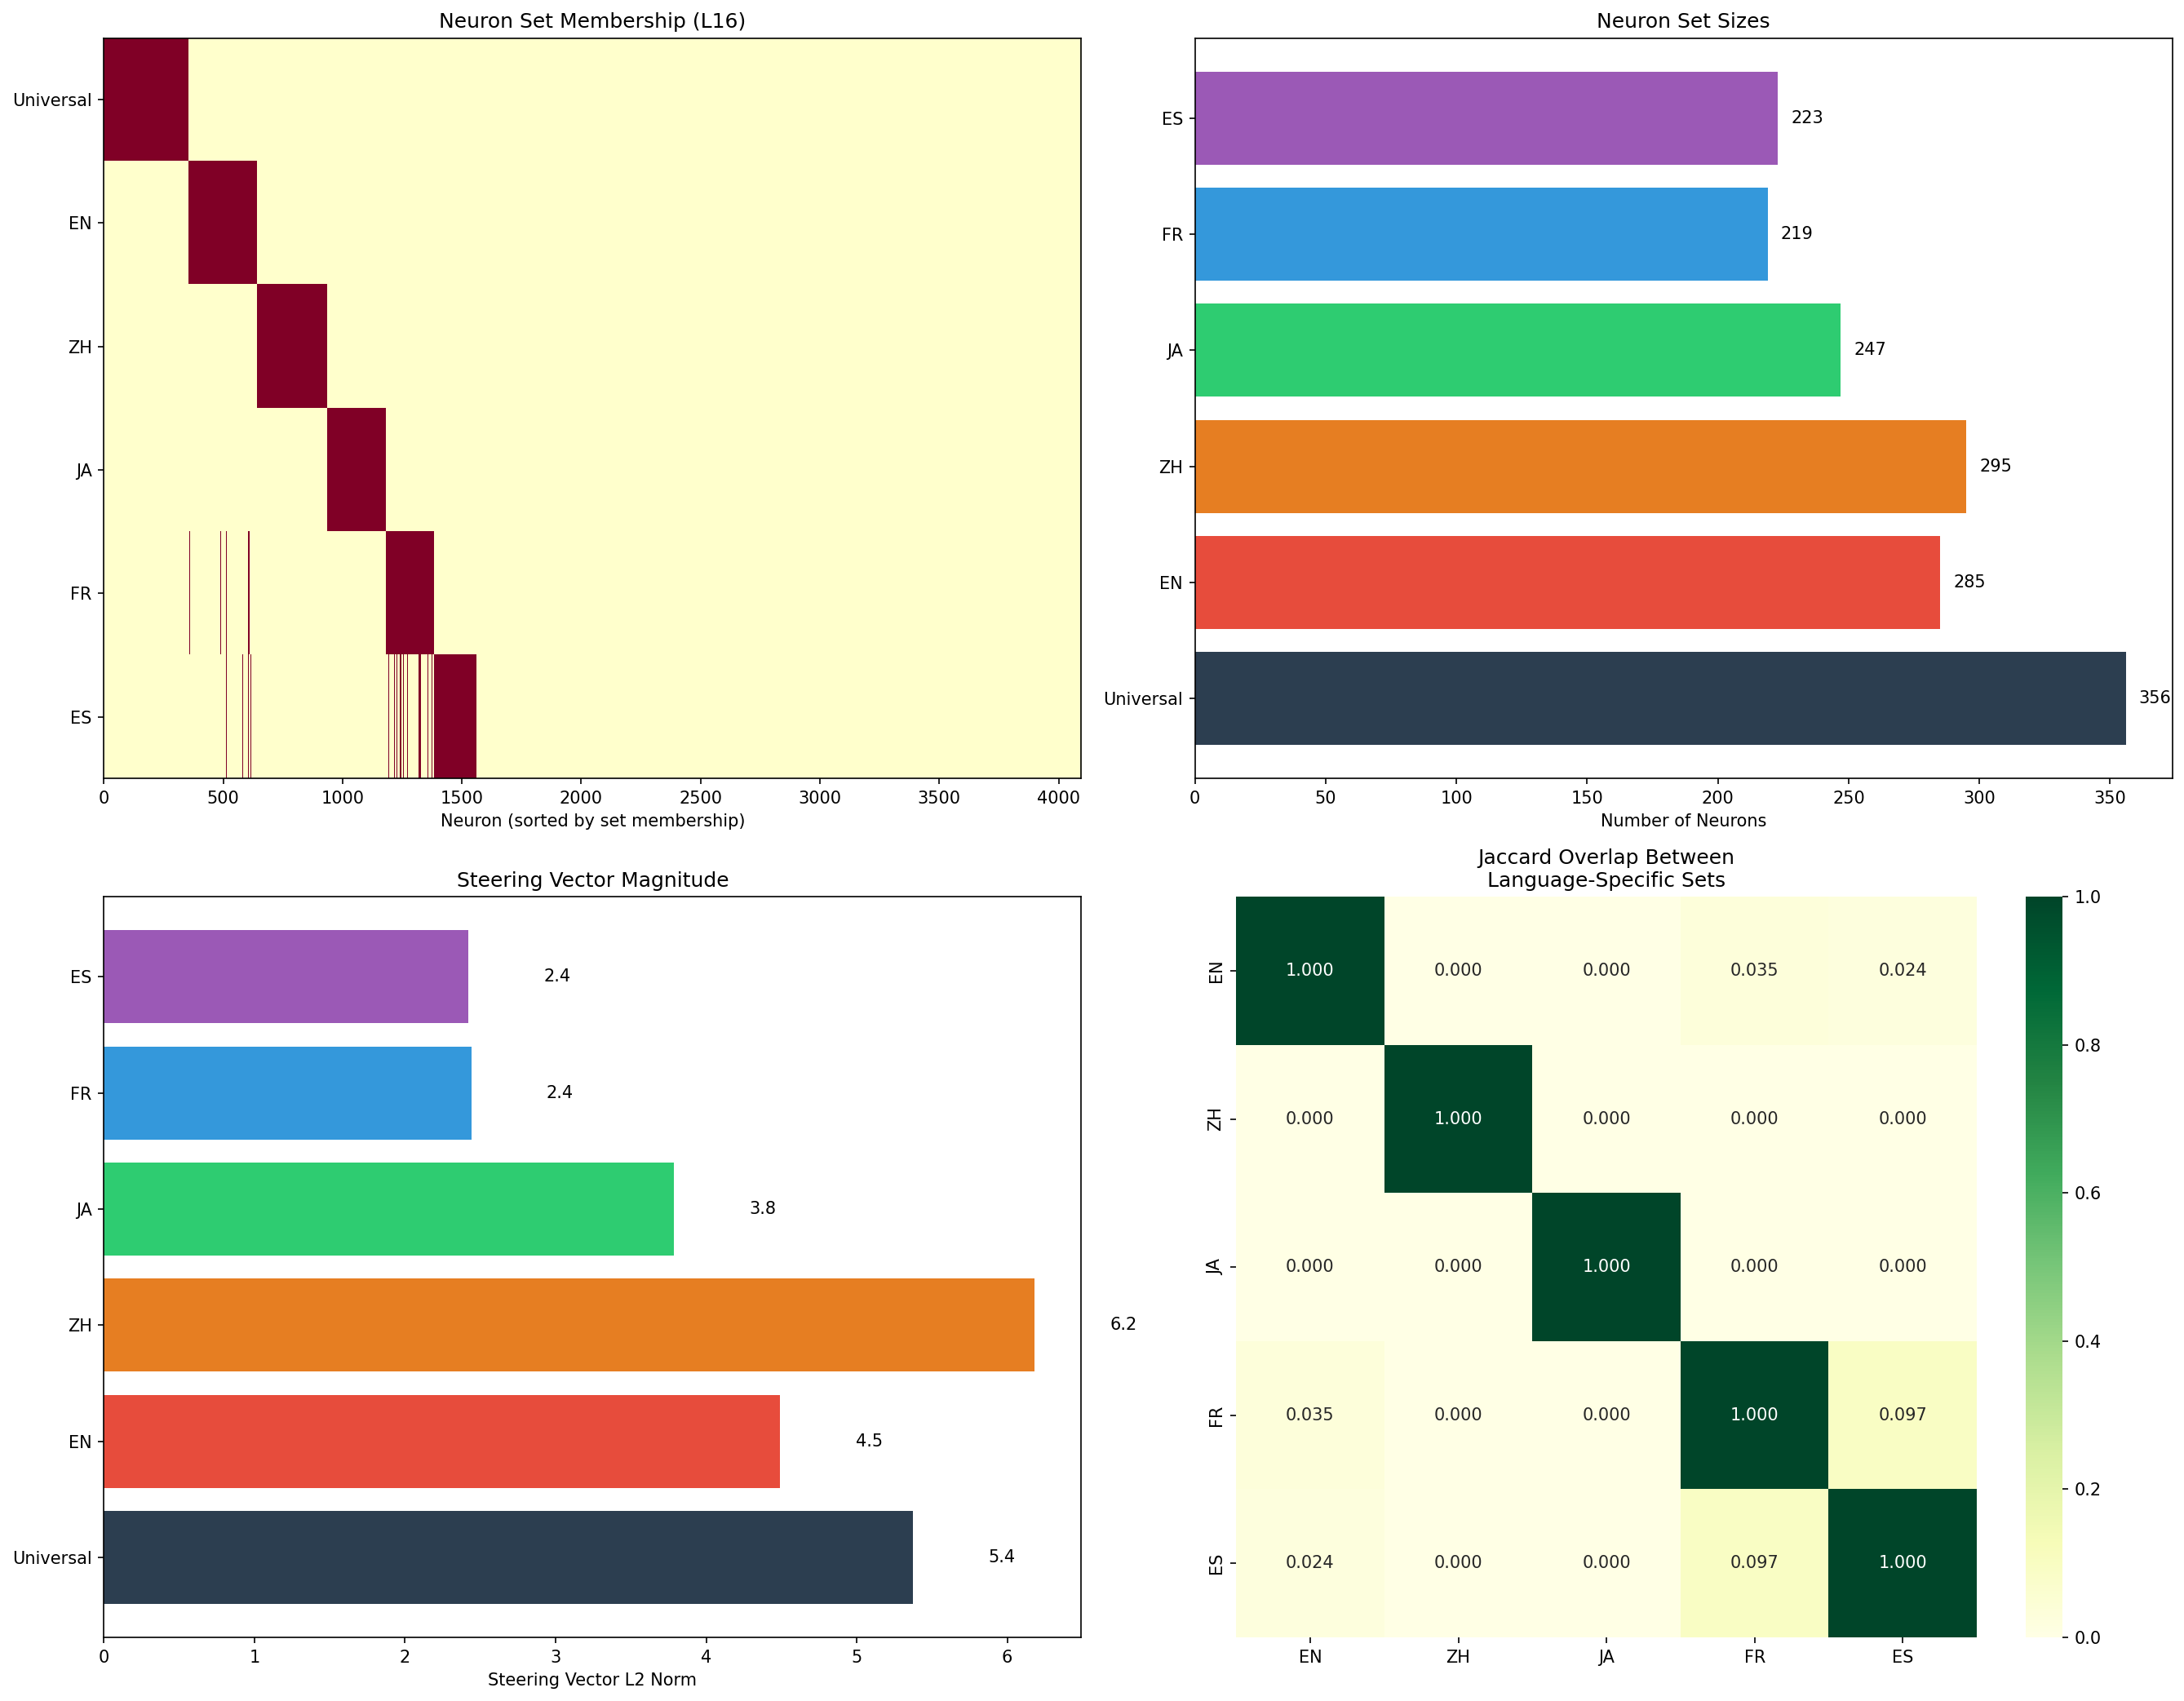


=== Steering Results Summary ===
  EN->ZH:  base=2.8%  steered=1.4%  delta=-1.4%
  EN->JA:  base=2.8%  steered=1.4%  delta=-1.3%
  ZH->EN:  base=0.0%  steered=0.0%  delta=+0.0%
  ZH->JA:  base=0.0%  steered=0.0%  delta=+0.0%
  JA->ZH:  base=0.0%  steered=0.0%  delta=+0.0%
  FR->JA:  base=0.0%  steered=0.0%  delta=+0.0%
Saved to /workspace/Data/aesthetic_neurons/cross_lingual_steering_results.npz


In [29]:
# === S12c: Visualize Neuron Sets + Steering Results ===
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# (a) Neuron set membership heatmap
ax = axes[0, 0]
set_membership = np.zeros((len(LANGS)+1, N_EMBD), dtype=np.float32)
set_membership[0, universal_set] = 1.0
for i, lang in enumerate(LANGS):
    if len(lang_specific_sets[lang]) > 0:
        set_membership[i+1, lang_specific_sets[lang]] = 1.0
# Sort neurons: universal first, then by language
order = []
added = set()
for n in universal_set:
    if n not in added: order.append(n); added.add(n)
for lang in LANGS:
    for n in lang_specific_sets[lang]:
        if n not in added: order.append(n); added.add(n)
for n in range(N_EMBD):
    if n not in added: order.append(n); added.add(n)
order = np.array(order)
im = ax.imshow(set_membership[:, order], aspect='auto', cmap='YlOrRd',
               interpolation='nearest', vmin=0, vmax=1)
ax.set_yticks(range(len(LANGS)+1))
ax.set_yticklabels(['Universal'] + LANGS)
ax.set_xlabel('Neuron (sorted by set membership)')
ax.set_title(f'Neuron Set Membership (L{best_layer})', fontsize=12)

# (b) Set sizes bar chart
ax = axes[0, 1]
set_sizes  = [len(universal_set)] + [len(lang_specific_sets[l]) for l in LANGS]
set_labels = ['Universal'] + LANGS
colors_sets = ['#2c3e50', '#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']
bars = ax.barh(set_labels, set_sizes, color=colors_sets)
for bar, sz in zip(bars, set_sizes):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(sz),
            va='center', fontsize=10)
ax.set_xlabel('Number of Neurons')
ax.set_title('Neuron Set Sizes', fontsize=12)

# (c) Steering vector norms
ax = axes[1, 0]
norms = [np.linalg.norm(universal_vec)] + [np.linalg.norm(lang_steering_vecs[l]) for l in LANGS]
bars = ax.barh(set_labels, norms, color=colors_sets)
for bar, n_val in zip(bars, norms):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{n_val:.1f}',
            va='center', fontsize=10)
ax.set_xlabel('Steering Vector L2 Norm')
ax.set_title('Steering Vector Magnitude', fontsize=12)

# (d) Pairwise Jaccard heatmap
ax = axes[1, 1]
sns.heatmap(jaccard_specific, annot=True, fmt='.3f', xticklabels=LANGS, yticklabels=LANGS,
            cmap='YlGn', vmin=0, vmax=1, ax=ax, square=True)
ax.set_title('Jaccard Overlap Between\nLanguage-Specific Sets', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_lingual_neuron_sets.png', dpi=150, bbox_inches='tight')
plt.show()

# Steering results summary
print(f'\n=== Steering Results Summary ===')
for (src, tgt), res in results.items():
    base_d  = aesthetic_density(res['baseline'])
    steer_d = aesthetic_density(res['steered'])
    print(f'  {src}->{tgt}:  base={base_d:.1f}%  steered={steer_d:.1f}%  delta={steer_d-base_d:+.1f}%')

# Save
np.savez(OUTPUT_DIR / 'cross_lingual_steering_results.npz',
         universal_set=universal_set,
         **{f'specific_{l}': lang_specific_sets[l] for l in LANGS},
         **{f'steer_vec_{l}': lang_steering_vecs[l] for l in LANGS},
         universal_vec=universal_vec,
         steer_pairs=np.array(STEER_PAIRS),
         jaccard_specific=jaccard_specific,
)
print(f'Saved to {OUTPUT_DIR / "cross_lingual_steering_results.npz"}')
